**Problem 1**. Consider a sample $X_n = \{x_1, \ldots, x_n\}$ of i.i.d. observations from Pareto distribution with PDF:

$$
f_X(x) = 
\begin{cases} 
\frac{\alpha x_m^\alpha}{x^{\alpha+1}} & x \geqslant x_m \\
0 & \text{otherwise}
\end{cases}
$$

with (unknown) parameters $x_m > 0$ (called scale), and $\alpha > 0$ (called shape). Denote $\theta = (\alpha, x_m)$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [2]:
alpha_true = 5
xm_true = 2
n_list = [100, 200, 500, 1000, 2000]

#### Task 2. QQ-plots

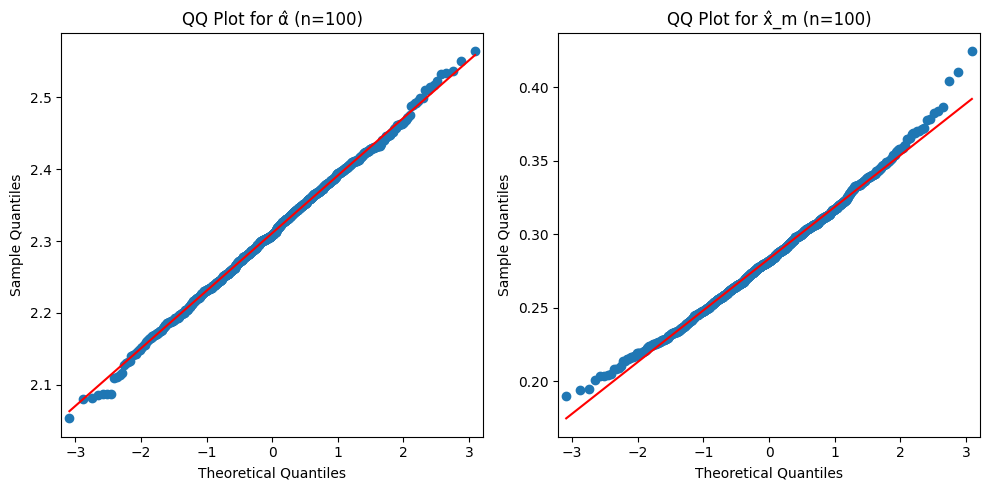

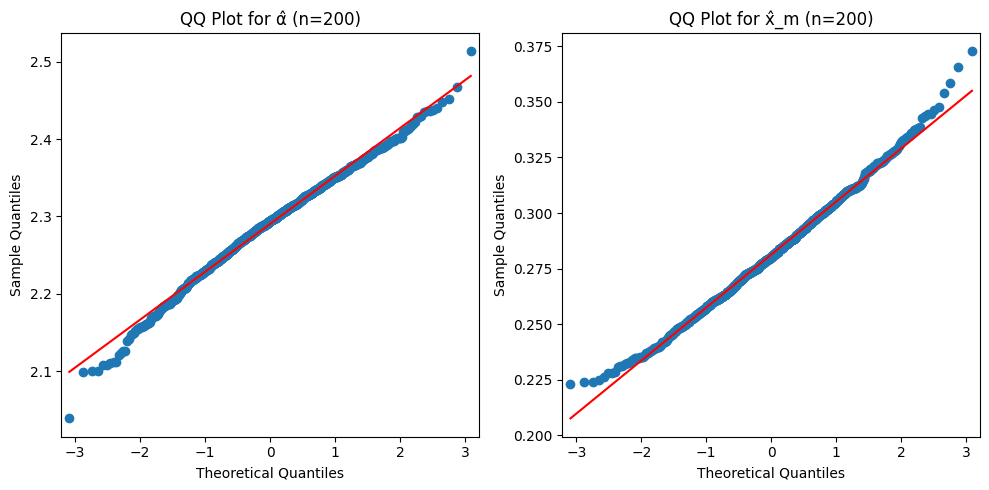

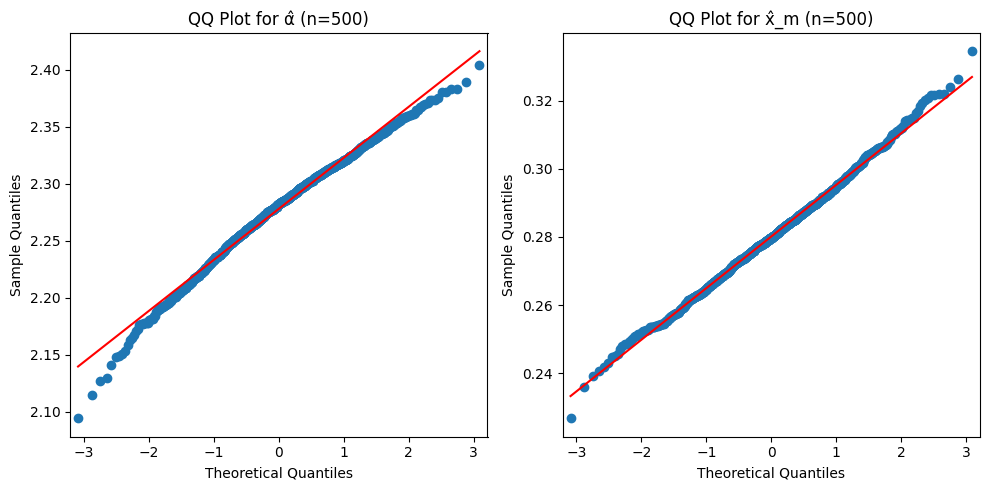

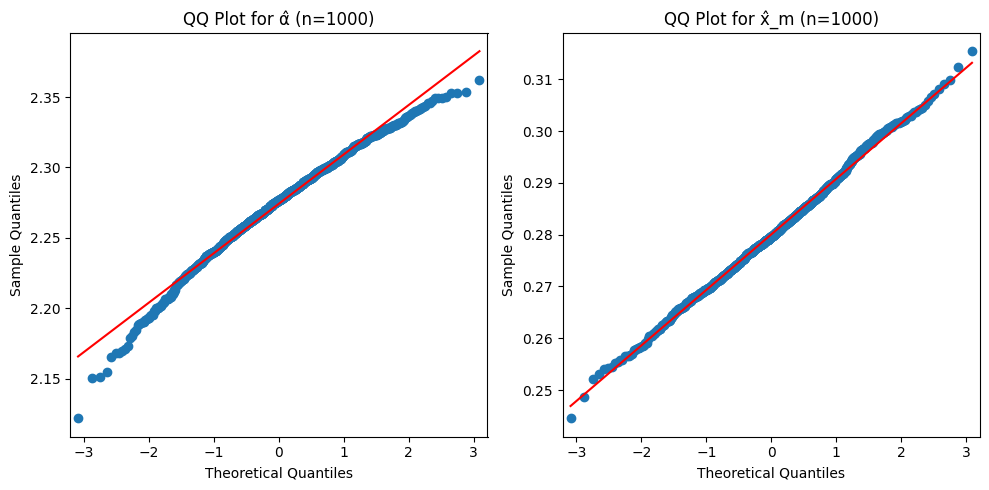

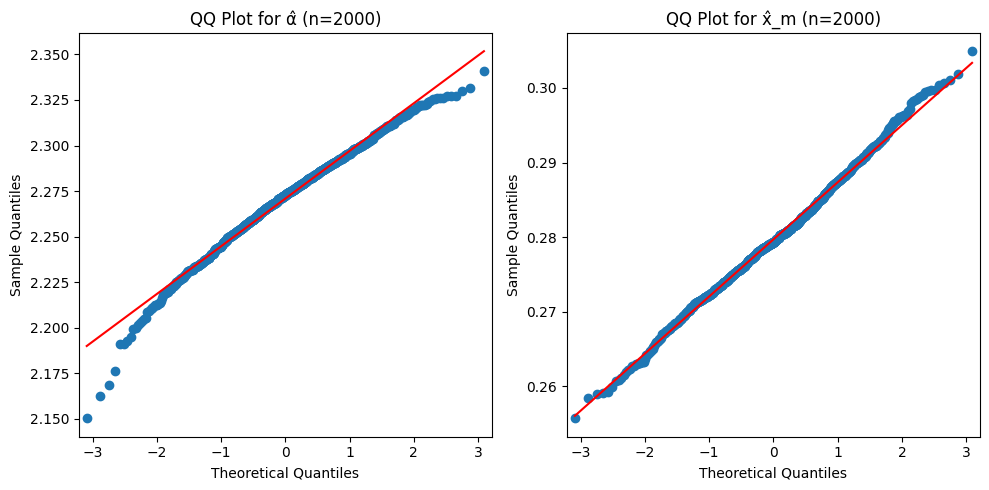

In [3]:
for n in n_list:
    bootstrap_alpha = []
    xm_list = []
    
    for _ in range(1_000):
        data = xm_true * np.random.pareto(alpha_true, size=n)
        
        sample_mean = np.mean(data)
        sample_second_moment = np.mean(data ** 2)
        
        k = (sample_mean ** 2) / sample_second_moment
        alpha = 1 + 1 / np.sqrt(1 - k)
        xm = sample_mean * (alpha - 1) / alpha
        
        bootstrap_alpha.append(alpha)
        xm_list.append(xm)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    sm.qqplot(np.array(bootstrap_alpha), line='s', ax=axes[0])
    axes[0].set_title(f'QQ Plot for α̂ (n={n})')
    sm.qqplot(np.array(xm_list), line='s', ax=axes[1])
    axes[1].set_title(f'QQ Plot for x̂_m (n={n})')
    plt.tight_layout()
    plt.show()

#### Task 3. Bootstrap

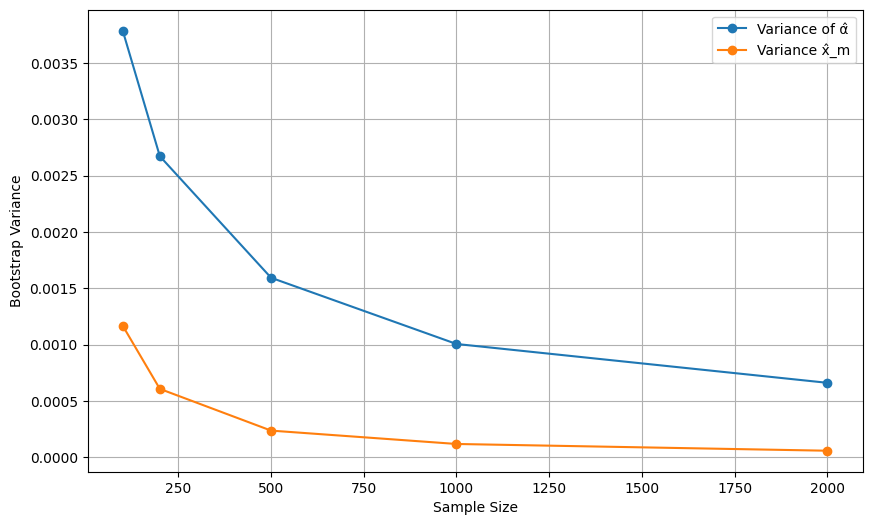

In [4]:
avg_var_alpha_list = []
avg_var_xm_list = []

for n in n_list:
    current_var_alpha = []
    current_var_xm = []
    
    for _ in range(100):
        for _ in range(1_000):
            data = xm_true * np.random.pareto(alpha_true, size=n)
            sample_mean = np.mean(data)
            sample_second_moment = np.mean(data ** 2)
            k = (sample_mean ** 2) / sample_second_moment
        
        # Bootstrap resampling
        bootstrap_alpha = []
        bootstrap_xm = []
        
        for _ in range(1000):
            bootstrap_sample = np.random.choice(data, size=n, replace=True)
            bootstrap_mean = np.mean(bootstrap_sample)
            boot_second_moment = np.mean(bootstrap_sample ** 2)
            k_boot = (bootstrap_mean ** 2) / boot_second_moment

            alpha_hat = 1 + 1 / np.sqrt(1 - k_boot)
            xm_hat = bootstrap_mean * (alpha_hat - 1) / alpha_hat
            bootstrap_alpha.append(alpha_hat)
            bootstrap_xm.append(xm_hat)
        
        current_var_alpha.append(np.var(bootstrap_alpha, ddof=1))
        current_var_xm.append(np.var(bootstrap_xm, ddof=1))

    avg_var_alpha_list.append(np.mean(current_var_alpha))
    avg_var_xm_list.append(np.mean(current_var_xm))


plt.figure(figsize=(10, 6))
plt.plot(n_list, avg_var_alpha_list, 'o-', label='Variance of α̂')
plt.plot(n_list, avg_var_xm_list, 'o-', label='Variance x̂_m')
plt.xlabel('Sample Size')
plt.ylabel('Bootstrap Variance')
plt.legend()
plt.grid(True)
plt.show()

#### Task 4.

In [5]:
def fisher_information_matrix(alpha, xm, n):
    I11 = n / alpha**2
    I12 = -n / xm
    I22 = n * alpha / xm**2
    return f"{I11}   {I12}\n{I12} {I22}"

n = 100
print("Fisher Information Matrix:")
print(fisher_information_matrix(alpha_true, xm_true, n))

Fisher Information Matrix:
4.0   -50.0
-50.0 125.0


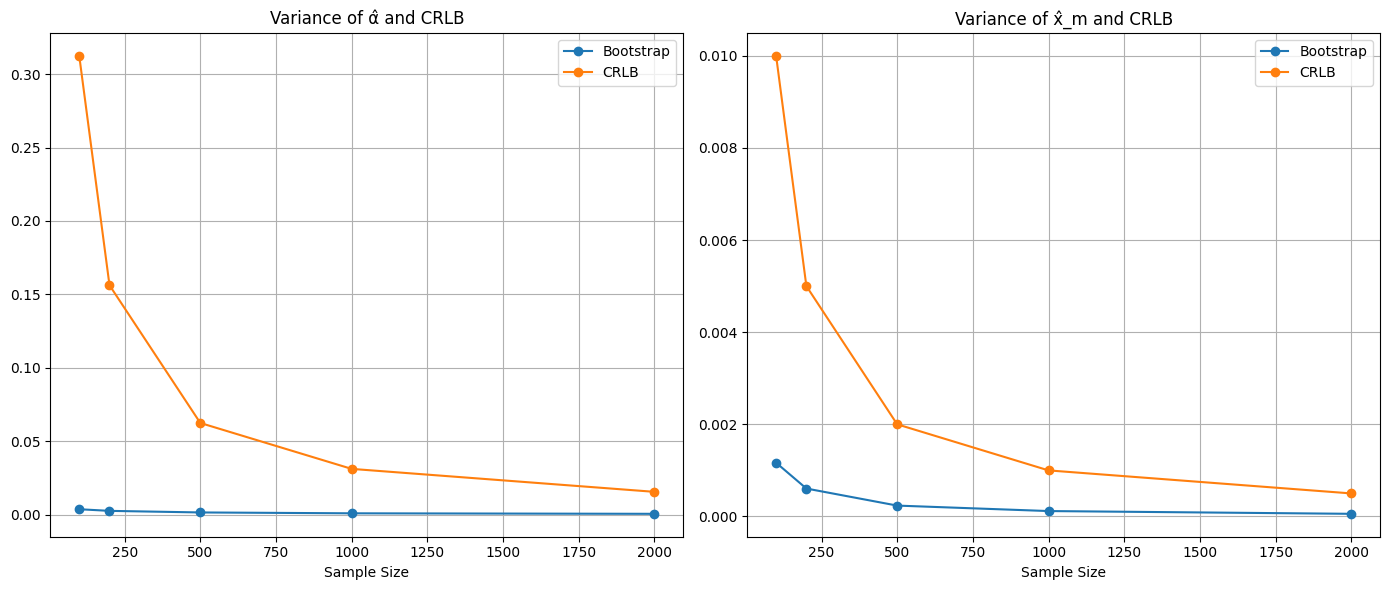

In [6]:
def count_crlb_alpha(n, alpha, xm):
    return (alpha ** 3) / (n * (alpha - 1))

def count_crlb_xm(n, alpha, xm):
    return (xm ** 2) / (n * (alpha - 1))


crlb_alpha = [count_crlb_alpha(n, alpha_true, xm_true) for n in n_list]
crlb_xm = [count_crlb_xm(n, alpha_true, xm_true) for n in n_list]


plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(n_list, avg_var_alpha_list, 'o-', label='Bootstrap')
plt.plot(n_list, crlb_alpha, 'o-', label='CRLB')
plt.xlabel('Sample Size')
plt.title('Variance of α̂ and CRLB')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(n_list, avg_var_xm_list, 'o-', label='Bootstrap')
plt.plot(n_list, crlb_xm, 'o-', label='CRLB')
plt.xlabel('Sample Size')
plt.title('Variance of x̂_m and CRLB')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()